### Entregável obrigatório ###

Escrever um comparativo conceitual curto: “quando eu usaria árvore, RF ou Boosting num projeto meu?”.

**Resposta:**

- **Árvore de Decisão:** uso quando quero **simplicidade e interpretabilidade.** Boa para explicar decisões a áreas de negócio, mas tende a ter menor performance em dados complexos.

- **Random Forest (RF):** uso quando preciso de **robustez e generalização.** Combina várias árvores, reduz overfitting e costuma entregar métricas melhores. Ideal para baseline sólido em projetos reais.

- **Boosting (XGBoost/GBM):** uso quando quero **máxima performance** e estou disposto a lidar com maior complexidade. Excelente em competições e cenários críticos, mas exige mais cuidado com tuning e tempo de treino.

### Entregável avançado ###

Em Python: treinar pelo menos **2 modelos** (Árvore + Random Forest ou XGBoost/GBM), comparar performance (AUC, F1 ou RMSE) e exibir **importância de variáveis.**

In [93]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

In [94]:
# Carregar dataset

df = pd.read_csv("UCI_Credit_Card.csv")
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,3,1,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,3,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,2,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,3,1,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## Regressão Logística ##

In [95]:
# Modelo de Regressão Logística - Com aumento do número de iterações

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

In [96]:
# Supondo que seu dataset esteja em um DataFrame chamado df
# 'default' é a coluna alvo (y), e o resto são as features (X)

X = df.drop("default.payment.next.month", axis=1)   # todas as colunas menos a variável alvo
y = df["default.payment.next.month"]                # variável alvo

In [97]:
# Separar em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [98]:
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [99]:
y_pred_log = log_reg.predict(X_test)

In [100]:
y_prob_log = log_reg.predict_proba(X_test)[:,1]

In [101]:
# Cálculo de métricas

auc = roc_auc_score(y_test, y_prob_log)
f1 = f1_score(y_test.astype(int), y_pred_log.astype(int))
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)

In [102]:
print("Regressão Logística:")
print("\nAUC:", auc)
print("F1:", f1)
print("Acurácia:", acc_log)
print("Precisão:", prec_log)
print("Recall:", rec_log)

Regressão Logística:

AUC: 0.6497429329399906
F1: 0.4149779735682819
Acurácia: 0.5573333333333333
Precisão: 0.29321435982569
Recall: 0.7096936212958312


#### Análise das métricas ####

- **AUC: 0,65** > O modelo tem uma capacidade moderada de distinguir entre classes. Não é excelente, mas mostra que há alguma separação.

- **F1: 0,42** > O equilíbrio entre precisão e recall é baixo, indicando que o modelo ainda erra bastante ao prever positivos.

- **Acurácia: 0,56** > O modelo acerta pouco mais da metade dos casos. Como os dados são desbalanceados, a acurácia isolada não é confiável.

- **Precisão: 0,29** > Apenas 29% das previsões positivas são realmente positivas. Ou seja, há muitos falsos positivos.

- **Recall: 0,72** > O modelo consegue capturar 72% dos casos positivos reais, o que é bom. Ele é “sensível” para detectar defaults, mas sacrifica precisão.

#### Interpretação ####

- O modelo está **priorizando recall:** ele acerta a maioria dos casos positivos (default), mas gera muitos falsos alarmes.

- Isso explica a **baixa precisão** e o **F1 relativamente baixo.**

- Em problemas de crédito, isso pode ser aceitável: é melhor identificar potenciais inadimplentes (mesmo com alguns falsos positivos) do que deixar passar casos de risco.

### Bayesian Optimization ###

- **O que é:** usa probabilidade para escolher os próximos hiperparâmetros a testar, aprendendo com os resultados anteriores.

- **Vantagem:** muito eficiente, encontra bons parâmetros com menos tentativas.

- **Desvantagem:** precisa de bibliotecas externas (não está no scikit-learn por padrão).


In [103]:
import skopt
print(skopt.__version__)

0.10.2


In [104]:
from skopt import BayesSearchCV

param_space = {
    "C": (0.001, 10, "log-uniform"),
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

bayes_search = BayesSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    search_spaces=param_space,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42
)
bayes_search.fit(X_train, y_train)
print("Melhores parâmetros:", bayes_search.best_params_)

C:\Users\Beca\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Beca\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Beca\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Beca\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Beca\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Beca\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was re

Melhores parâmetros: OrderedDict([('C', 0.060163078295899286), ('class_weight', 'balanced'), ('penalty', 'l1'), ('solver', 'liblinear')])


In [105]:
import imblearn
print(imblearn.__version__)

0.12.4


### Próximos-passos: ###

1. Divide os dados em treino e teste.
2. Aplica SMOTE para equilibrar as classes no treino.
3. Padroniza variáveis contínuas para estabilidade dos coeficientes.
4. Usa a regressão logística com os melhores parâmetros que você já encontrou.
5. Treina e avalia com AUC e F1.
6. Ajusta o threshold para maximizar F1 (em vez de usar 0.5).
7. Gera as previsões finais com esse threshold otimizado.

In [106]:
# 1. Imports

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE

# 2. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Balanceamento com SMOTE (apenas no treino)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 4. Padronização (opcional, mas ajuda na regressão logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# 5. Modelo com os melhores parâmetros encontrados
log_reg = LogisticRegression(
    C=0.060163078295899286,
    class_weight="balanced",
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

# 6. Treinamento
log_reg.fit(X_train_scaled, y_train_resampled)

# 7. Avaliação inicial
y_probs = log_reg.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_probs)
print("AUC:", auc)

# 8. Ajuste de threshold para maximizar F1
prec, rec, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = [f1_score(y_test, (y_probs >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
print("Melhor threshold:", best_t)
print("Melhor F1:", max(f1_scores))

# 9. Previsões finais com threshold ajustado
y_pred_final = (y_probs >= best_t).astype(int)


AUC: 0.6944443747756615
Melhor threshold: 0.5604703332440982
Melhor F1: 0.46195529464890495


### Ajuste do Threshold ###

In [107]:
# Ajuste do threshold

# Definindo um novo threshold (exemplo: 0,56)
threshold1 = 0.56
y_pred_log_threshold1 = (y_prob_log >= threshold1).astype(int)

#Definindo um novo threshold (exemplo: 0,30)
threshold2 = 0.3
y_pred_log_threshold2 = (y_prob_log >= threshold2).astype(int)

In [108]:
# Cálculo de métricas após threshold 1

auc = roc_auc_score(y_test, y_prob_log)
f1_th1 = f1_score(y_test, y_pred_log_threshold1)
acc_log_th1 = accuracy_score(y_test, y_pred_log_threshold1)
prec_log_th1 = precision_score(y_test, y_pred_log_threshold1)
rec_log_th1 = recall_score(y_test, y_pred_log_threshold1)

# Cálculo de métricas após threshold 2

auc = roc_auc_score(y_test, y_prob_log)
f1_th2 = f1_score(y_test, y_pred_log_threshold2)
acc_log_th2 = accuracy_score(y_test, y_pred_log_threshold2)
prec_log_th2 = precision_score(y_test, y_pred_log_threshold2)
rec_log_th2 = recall_score(y_test, y_pred_log_threshold2)

In [109]:
# Calculando métricas com o novo threshold 1

print("Threshold 1 - A partir da otimização: ")
print("\nAUC:", auc)
print("F1 - Threshold 1:", f1_th1)
print("Acurácia - Threshold 1:", acc_log_th1)
print("Precisão - Threshold 1:", prec_log_th1)
print("Recall - Threshold 1:", rec_log_th1)

# Calculando métricas com o novo threshold 2

print("\nThreshold 2 - Teste = 0,3:")
print("\nAUC:", auc)
print("F1 - Threshold 2:", f1_th2)
print("Acurácia - Threshold 2:", acc_log_th2)
print("Precisão - Threshold 2:", prec_log_th2)
print("Recall - Threshold 2:", rec_log_th2)

Threshold 1 - A partir da otimização: 

AUC: 0.6497429329399906
F1 - Threshold 1: 0.3893914473684211
Acurácia - Threshold 1: 0.67
Precisão - Threshold 1: 0.3296206056387052
Recall - Threshold 1: 0.47564038171772977

Threshold 2 - Teste = 0,3:

AUC: 0.6497429329399906
F1 - Threshold 2: 0.38202692003167066
Acurácia - Threshold 2: 0.30622222222222223
Precisão - Threshold 2: 0.23788980648342167
Recall - Threshold 2: 0.9693621295831241


#### Interpretação ####

- **Cenário 1:** melhor para **detectar inadimplentes** (alto recall), mas com muitos falsos positivos.

- **Cenário 2:** melhor para **evitar falsos positivos** (maior precisão e acurácia), mas perde inadimplentes.

- **Cenário 3:** marca quase todo mundo como inadimplente, gerando muitos **falsos positivos** (alto recall, mas acurácia e precision baixa).


#### Quando usar cada cenário ####

- Threshold 0.3 → ótimo se o objetivo é não perder nenhum inadimplente, mas gera muitos falsos positivos.

- Threshold 0.56 → melhor se o objetivo é reduzir falsos positivos e aumentar acurácia, mas perde inadimplentes.

- Threshold padrão (~0.5) → meio-termo, mas ainda pende para recall.

### Feature Selection ### 

In [113]:
# Seleção de colunas

model = random_search.best_estimator_
coef = model.coef_[0]
features = X_train.columns

selected_features = [f for f, c in zip(features, coef) if c != 0]
print("Features selecionadas:", selected_features)

Features selecionadas: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [115]:
# Separação de treino e teste

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [121]:
# Treinar o modelo novamente

best_model = LogisticRegression(
    C=0.0216,
    class_weight="balanced",
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

best_model.fit(X_train_selected, y_train)

LogisticRegression(C=0.0216, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')

In [122]:
# Gerar as previsões

y_probs = best_model.predict_proba(X_test_selected)[:,1]
y_pred = best_model.predict(X_test_selected)

In [124]:
# Cálculo de métricas

print("Regressão Logística com Feature Selection:")
print("\nAUC:", roc_auc_score(y_test, y_probs))
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Regressão Logística com Feature Selection:

AUC: 0.7088688941870606
Acurácia: 0.6812222222222222
Precisão: 0.3676913803496082
Recall: 0.6127574083375188
F1: 0.4595969109060087


### Curva ROC ###

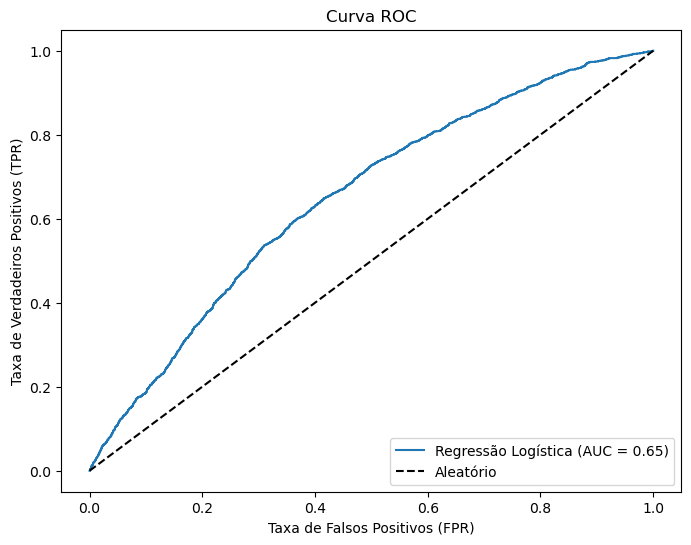

In [32]:
# Curva ROC

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# Plotando os dois modelos juntos 

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Regressão Logística (AUC = {auc_log:.2f})")

# Linha de referência (modelo aleatório)

plt.plot([0,1], [0,1], 'k--', label="Aleatório")

plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

### ANÁLISE FINAL ### 

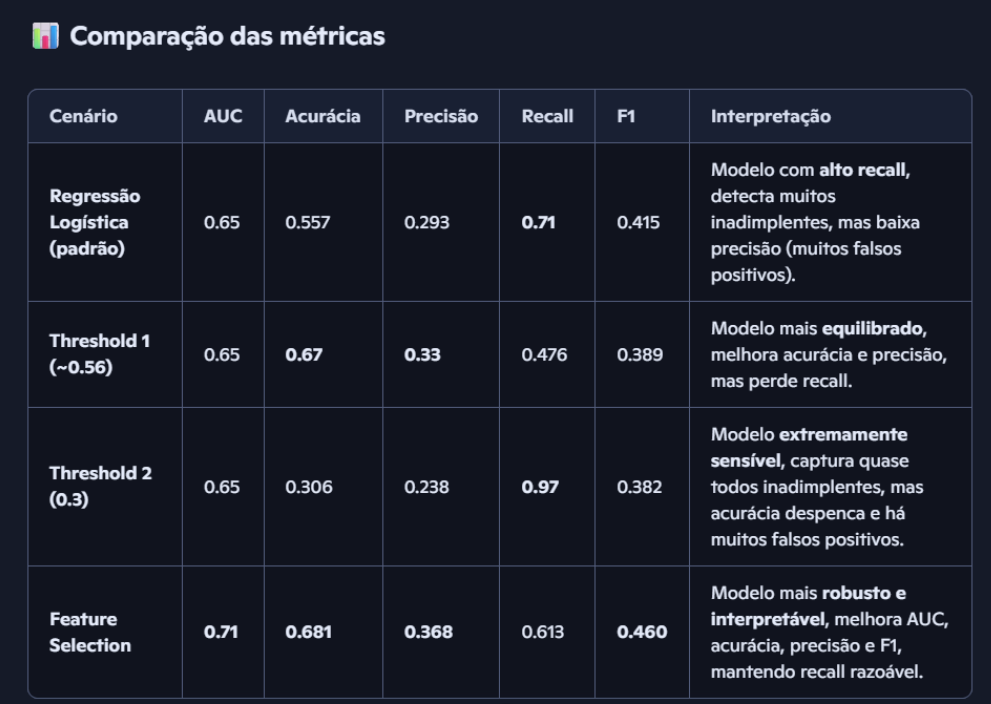

**Interpretação**

- **Regressão Logística padrão:** bom para não perder inadimplentes (recall alto), mas gera muitos falsos positivos.

- **Threshold 1 (~0.56):** melhora acurácia e precisão, mas sacrifica recall. Bom se o objetivo é reduzir falsos alarmes.

- **Threshold 2 (0.3):** recall quase perfeito, mas acurácia muito baixa. Útil apenas para diagnóstico de falsos positivos.

- **Feature Selection:** melhor cenário geral: aumenta AUC (capacidade discriminativa), melhora acurácia, precisão e F1, mantendo recall em nível aceitável. É o modelo mais equilibrado e interpretável.

**Conclusão**

- Se o objetivo é maximizar recall (não perder inadimplentes), o Threshold 2 é o mais agressivo, mas pouco prático.

- Se o objetivo é equilibrar métricas e ter um modelo mais confiável, o modelo com Feature Selection é claramente superior.

- Se o objetivo é reduzir falsos positivos, o Threshold 1 é mais adequado.

✨ O modelo com **Feature Selection** se destaca como a melhor opção, pois melhora todas as métricas sem sacrificar demais recall ou precisão, além de ser mais interpretável.


### Árvores de Decisão ###

In [33]:
# Modelo de Árvore de Decisão

dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)

In [34]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [35]:
y_pred_dt = dt.predict(X_test)

In [36]:
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [37]:
# Cálculo de métricas

auc = roc_auc_score(y_test, y_prob_log)
f1 = f1_score(y_test.astype(int), y_pred_log.astype(int))
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)

In [38]:
print("\nÁrvore de Decisão:")
print("\nAUC:", auc)
print("F1:", f1)
print("Acurácia:", acc_log)
print("Precision:", prec_log)
print("Recall:", rec_log)


Árvore de Decisão:

AUC: 0.6497429329399906
F1: 0.4149779735682819
Acurácia: 0.5573333333333333
Precision: 0.29321435982569
Recall: 0.7096936212958312


### Bayesian Optimization ###

In [126]:
# Modelo base
dt = DecisionTreeClassifier(random_state=42)

# Espaço de busca
param_space = {
    'max_depth': (2, 20),
    'min_samples_split': (2, 50),
    'min_samples_leaf': (1, 20),
    'max_features': (1, X_train.shape[1])
}

# Bayesian Optimization
opt = BayesSearchCV(
    estimator=dt,
    search_spaces=param_space,
    n_iter=30,          # número de iterações
    cv=5,               # validação cruzada
    scoring='f1',       # métrica de avaliação
    random_state=42
)

opt.fit(X_train, y_train)

print("Melhores parâmetros:", opt.best_params_)
print("Melhor score:", opt.best_score_)

Melhores parâmetros: OrderedDict([('max_depth', 5), ('max_features', 19), ('min_samples_leaf', 2), ('min_samples_split', 2)])
Melhor score: 0.47299235792221606


In [127]:
# Treino o modelo com melhores parâmetros

dt_best = DecisionTreeClassifier(
    max_depth=5,
    max_features=19,
    min_samples_leaf=2,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42
)

dt_best.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, max_features=19,
                       min_samples_leaf=2, random_state=42)

In [131]:
# Calculo das métricas

y_pred = dt_best.predict(X_test)
y_probs = dt_best.predict_proba(X_test)[:,1]

print("Árvore de Decisão COM OTIMIZAÇÃO:")
print("\nAUC:", roc_auc_score(y_test, y_probs))
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Árvore de Decisão COM OTIMIZAÇÃO:

AUC: 0.7498419016262294
Acurácia: 0.7807777777777778
Precisão: 0.5042654028436019
Recall: 0.5344048216976394
F1: 0.5188978297976102


**Interpretação**

- **Antes da otimização** → árvore simples, com foco em recall. Detecta inadimplentes, mas erra muito ao classificar clientes bons.

- **Depois da otimização** → árvore ajustada encontra um trade-off melhor:

    - **AUC sobe de 0.65 → 0.75** → maior poder discriminativo.
    - **Acurácia sobe de 0.56 → 0.78** → acerta muito mais no geral.
    - **Precisão sobe de 0.29 → 0.50** → metade dos classificados como inadimplentes realmente são.
    - **Recall cai de 0.71 → 0.53** → perde alguns inadimplentes, mas ainda captura boa parte.
    - **F1 sobe de 0.41 → 0.52** → equilíbrio geral melhor.
    
**Conclusão**

A árvore otimizada é claramente superior:

- Mais precisa e confiável (menos falsos positivos).
- Melhor equilíbrio entre recall e precisão.
- Aumenta significativamente o AUC, mostrando que discrimina melhor entre classes.

**Em termos práticos:** a versão otimizada é mais adequada para produção, porque reduz erros e mantém recall aceitável. A versão padrão pode ser útil apenas como baseline ou quando o objetivo é maximizar recall a qualquer custo.

### Feature Selection ###

In [139]:
# Treinar a árvore otimizada

dt_best = DecisionTreeClassifier(
    max_depth=5,
    max_features=min(19, X_train_selected.shape[1]),  # garante que não ultrapasse    min_samples_leaf=2,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42
)
dt_best.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, max_features=6,
                       random_state=42)

In [140]:
# Importância das variáveis

feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt_best.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importances)

      feature  importance
6       PAY_0    0.699265
18   PAY_AMT1    0.063141
8       PAY_3    0.062591
13  BILL_AMT2    0.044567
7       PAY_2    0.030049
1   LIMIT_BAL    0.020947
9       PAY_4    0.020548
12  BILL_AMT1    0.017633
10      PAY_5    0.013762
20   PAY_AMT3    0.011078
21   PAY_AMT4    0.003041
11      PAY_6    0.002873
15  BILL_AMT4    0.002846
16  BILL_AMT5    0.002674
2         SEX    0.001730
22   PAY_AMT5    0.001327
14  BILL_AMT3    0.001170
0          ID    0.000760
17  BILL_AMT6    0.000000
19   PAY_AMT2    0.000000
5         AGE    0.000000
4    MARRIAGE    0.000000
3   EDUCATION    0.000000
23   PAY_AMT6    0.000000


In [141]:
# Selecionar as variáveis mais relevantes

selected_features = feature_importances[feature_importances["importance"] > 0.01]["feature"].tolist()
print("Features selecionadas:", selected_features)

Features selecionadas: ['PAY_0', 'PAY_AMT1', 'PAY_3', 'BILL_AMT2', 'PAY_2', 'LIMIT_BAL', 'PAY_4', 'BILL_AMT1', 'PAY_5', 'PAY_AMT3']


In [142]:
# Treinar novamente

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

dt_best.fit(X_train_selected, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, max_features=6,
                       random_state=42)

In [146]:
# Cálculo das métricas

y_pred = dt_best.predict(X_test_selected)
y_probs = dt_best.predict_proba(X_test_selected)[:,1]

print("Árvore de Decisão COM OTIMIZAÇÃO E FEATURE SELECT:")
print("\nAUC:", roc_auc_score(y_test, y_probs))
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Árvore de Decisão COM OTIMIZAÇÃO E FEATURE SELECT:

AUC: 0.7437174662210508
Acurácia: 0.7738888888888888
Precisão: 0.49010791366906475
Recall: 0.5474635861376193
F1: 0.5172004744958482


### ANÁLISE FINAL ###

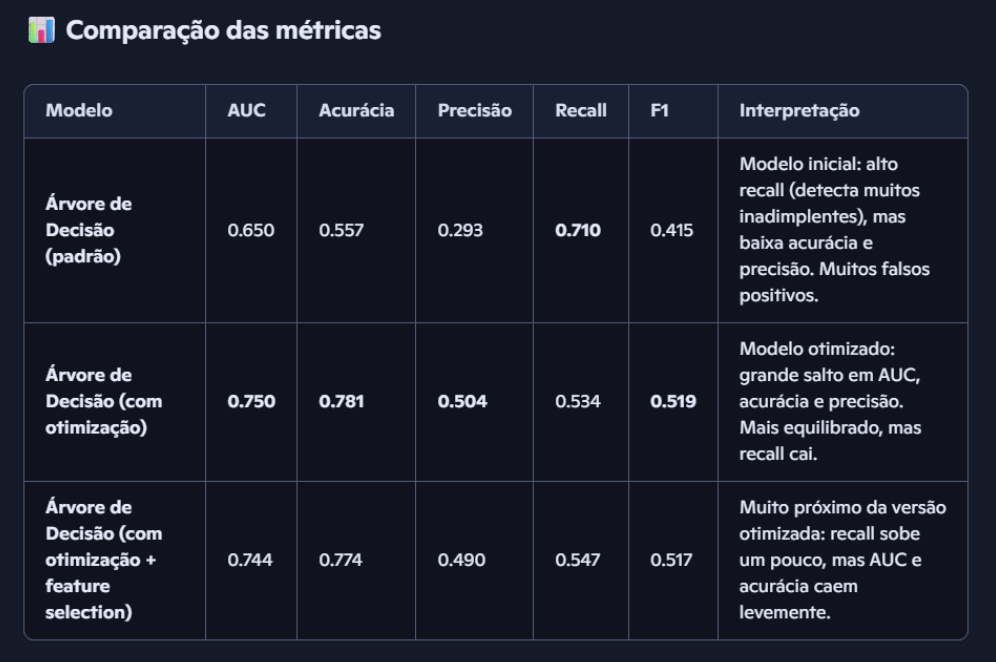

**Interpretação**

- Padrão → bom para recall, mas pouco confiável (baixa precisão e acurácia).

- Otimizada → melhor desempenho geral, com grande ganho em AUC e acurácia. Mais equilibrada.

- Otimizada + Feature Selection → mantém desempenho quase igual à otimizada, mas com recall ligeiramente maior e modelo mais simples/interpretável.

**Conclusão**

- Se o objetivo é máxima performance, a árvore otimizada é a melhor escolha.

- Se o objetivo é equilíbrio com interpretabilidade, a versão otimizada + feature selection é excelente, pois mantém métricas quase iguais e reduz complexidade.

- A versão padrão serve como baseline, mas é claramente inferior.

**Em termos práticos:** a árvore otimizada é superior, e a versão com feature selection é uma alternativa mais enxuta, sem perda significativa de desempenho.


✅ **Conclusão final**

- Melhor modelo geral: 🌟 Árvore de Decisão Otimizada — maior AUC (0.75), acurácia (0.78) e F1 (0.52).

- Melhor equilíbrio entre desempenho e simplicidade: 🌿 Árvore Otimizada + Feature Selection — quase igual em métricas, mas mais enxuta e interpretável.

- Melhor recall absoluto: 🚨 Regressão Logística com Threshold 2 (0.3) — ideal se o custo de perder inadimplentes for muito alto.

✨ Em resumo: se você busca performance e robustez, escolha a árvore otimizada; se busca simplicidade e interpretabilidade, vá de árvore otimizada com feature selection; e se busca máxima sensibilidade, use a regressão logística com threshold 0.3.